## Indicate Dynawo and Modelica package.mo

In [ ]:
#=  The env variable DYNAWO_PATH must has be set beforehands to the root of the dynawo code.
    In case you are only working with the library distribution, the second part of the expression must be slightly modified.
    Anyway the package_file should be pointing to the package.mo file of the Dynawo library you want to use
=#

# Ruta de la librería Dynawo
ENV["DYNAWO_PATH"] = "/.../dynawo/dynawo/sources/Models/Modelica/Dynawo"
Dynawo_package_file = string(ENV["DYNAWO_PATH"], "/package.mo")

# Ruta de la librería Modelica (ajusta según tu instalación)
ENV["MODELICA_PATH"] = "/.../dynawo/OpenModelica/lib/omlibrary/Modelica"
Modelica_package_file = string(ENV["MODELICA_PATH"], "/package.mo")

## Import packages and data

In [2]:
using OMJulia
using Plots, DataFrames, CSV

In [ ]:
# Load the dynamic model
SMIB = OMJulia.OMCSession()
ModelicaSystem(SMIB,Dynawo_package_file,"Dynawo.Examples.SMIB.SMIBStepPm",[Modelica_package_file])

# Load the auxiliary static model
StaticSMIB = OMJulia.OMCSession()
ModelicaSystem(StaticSMIB,Dynawo_package_file,"Dynawo.Examples.SMIB.StaticSMIB",[Modelica_package_file])

## Run initial simulation

We are using the model Dynawo.Examples.SMIB.SMIBStepPm from the Dynawo Modelica library in the master release. This model includes a generator of class Dynawo.Examples.BaseClasses.GeneratorSynchronousInterfaces , which has built-in initialization via the INIT model Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronousInt_INIT .

We check that we can load the model, run a simulation with OMJulia and plot some results.

WebIO._IJuliaInit()

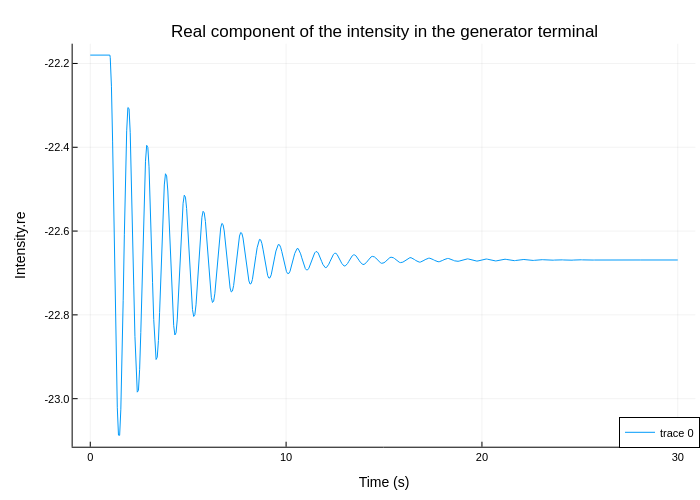

In [4]:
# Run the simulation of the dynamic model
resultfile_name = string("SMIB_base", ".csv")
simulate(SMIB,resultfile = resultfile_name,
                simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(SMIB), resultfile_name)
df = DataFrame(CSV.File(resultfile));

# Plot the real component of the intensity in the generator terminal
plotlyjs()
p2 = plot(df[!, "time"], df[!, "generatorSynchronous.terminal.i.re"], label=["Generator i.re"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Real component of the intensity in the generator terminal")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Intensity.re")  

## Initialization with a static model

We want to test the initialization strategy of building a static model that includes the initial power flow and the INIT model.

In the static model (Dynawo.Examples.SMIB.StaticSMIB), we replace the synchronous generator by a simplified generator with fixed PV. We also include the GeneratorSynchronousInt_INIT and the initial algorithm.

The initial power flow allows us to initialize the GeneratorSynchronousInt_INIT model, which requires the initial values of complex voltage and complex power.

We can check that we obtain the same result.

In [ ]:
# Run the simulation of the auxiliary static model
simulate(StaticSMIB)

# Extract the model continuous variables
(MsalPu) = getContinuous(StaticSMIB, ["gen_INIT.MsalPu"]);

# Set the values of the parameters of the dynamic model
setParameters(SMIB, [
    "generatorSynchronous.MsalPu = " * string(MsalPu),
])

generatorSynchronous.MsalPu=Any[0.04999999999999982]



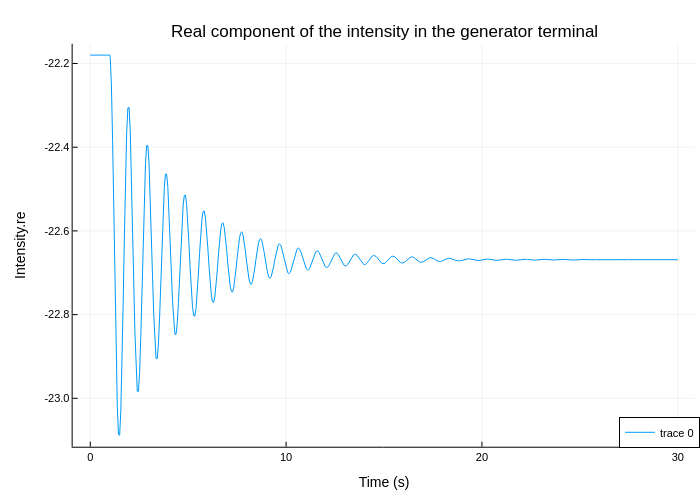

In [7]:
# Run the simulation of the dynamic model
resultfile_name = string("SMIB_base", ".csv")
simulate(SMIB,resultfile = resultfile_name,
                simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(SMIB), resultfile_name)
df = DataFrame(CSV.File(resultfile));

# Plot the real component of the intensity in the generator terminal
plotlyjs()
p2 = plot(df[!, "time"], df[!, "generatorSynchronous.terminal.i.re"], label=["Generator i.re"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Real component of the intensity in the generator terminal")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Intensity.re")  

## Modification of the line 1 reactance

We can change some of the model parameters, such as the line reactance. The dynamic model adjusts the parameters of the synchronous generator automatically, since it has built-in initialization.

In [ ]:
myXpu = 0.03

# Load the dynamic model
SMIB = OMJulia.OMCSession()
ModelicaSystem(SMIB,Dynawo_package_file,"Dynawo.Examples.SMIB.SMIBStepPm",[Modelica_package_file])

# Load the auxiliary static model
StaticSMIB = OMJulia.OMCSession()
ModelicaSystem(StaticSMIB,Dynawo_package_file,"Dynawo.Examples.SMIB.StaticSMIB",[Modelica_package_file])

line1.XPu=0.03



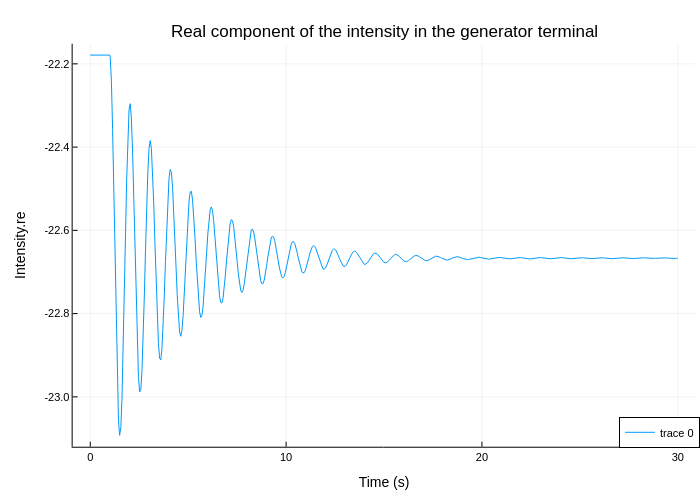

In [9]:
# Modify the line1 reactance
setParameters(SMIB, ["line1.XPu = " * string(myXpu)])
buildModel(SMIB)

# Run the simulation of the dynamic model
resultfile_name = string("SMIB_base", ".csv")
simulate(SMIB,resultfile = resultfile_name,
                simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(SMIB), resultfile_name)
df = DataFrame(CSV.File(resultfile));

# Plot the real component of the intensity in the generator terminal
plotlyjs()
p2 = plot(df[!, "time"], df[!, "generatorSynchronous.terminal.i.re"], label=["Generator i.re"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Real component of the intensity in the generator terminal")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Intensity.re") 

## Initialization with the modified line reactance

If instead we initialise the model by using the auxiliary static model, the new initial parameter values are calculated automatically. We can check that the obtained result coincides with the dynamic model.

In [ ]:
# Modify the line1 reactance
setParameters(StaticSMIB, ["line1.XPu = " * string(myXpu)])
buildModel(StaticSMIB)

# Run the simulation of the auxiliary static model
simulate(StaticSMIB)

# Extract the model continuous variables
(MsalPu) = getContinuous(StaticSMIB, ["gen_INIT.MsalPu"]);

# Set the initial values of the parameters of the dynamic model
setParameters(SMIB, [
    "generatorSynchronous.MsalPu = " * string(MsalPu),
])

generatorSynchronous.MsalPu=Any[0.04999999999999982]

line1.XPu=0.03



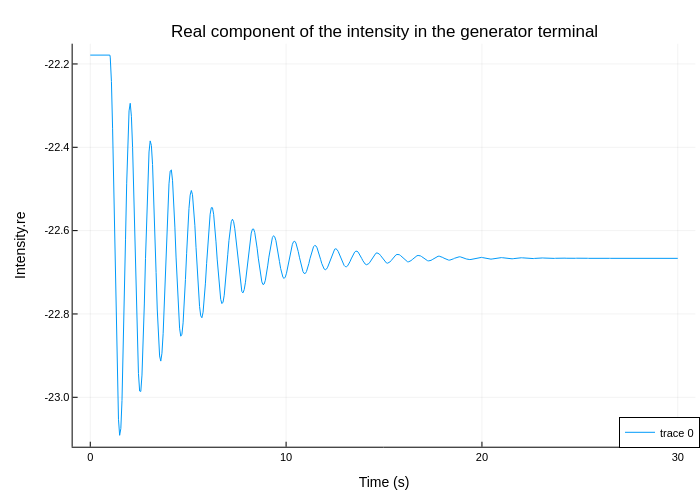

In [11]:
# Run the simulation of the dynamic model
resultfile_name = string("SMIB_base", ".csv")
simulate(SMIB,resultfile = resultfile_name,
                simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(SMIB), resultfile_name)
df = DataFrame(CSV.File(resultfile));

# Plot the real component of the intensity in the generator terminal
plotlyjs()
p2 = plot(df[!, "time"], df[!, "generatorSynchronous.terminal.i.re"], label=["Generator i.re"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Real component of the intensity in the generator terminal")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Intensity.re")  